# 📚 Análise de Avaliações de Livros — EDA e Validação de Hipóteses
**Case técnico — NLP e LLMs sobre avaliações de livros**

**Contexto de negócio:** a editora leva ~3 dias e 5 analistas para explorar avaliações
manualmente. Este notebook demonstra o pipeline que automatiza essa exploração e valida
as hipóteses que guiaram a solução.

| # | Hipótese |
|---|----------|
| H1 | A nota média esconde insatisfação — o viés positivo das estrelas inflaciona a percepção |
| H2 | Poucos leitores concentram os votos de utilidade → shortlist objetiva para entrevistas |
| H3 | O sentimento do **texto** discrimina melhor que as estrelas (3★ é ambíguo, o texto não) |
| H4 | Os aspectos criticados variam por gênero → ação editorial direcionada |
| H5 | Cauda longa: poucos títulos concentram as reviews → esforço manual mal alocado |

> Rodando com a **amostra sintética** (mesmo schema do Kaggle). Para os dados reais,
> coloque os CSVs em `data/raw/` — nenhuma célula muda.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')  # trabalhar a partir da raiz do repo
sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_data
from src.nlp_pipeline import add_sentiment, aspect_sentiment, extract_topics, rank_reviewers

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

df = load_data()
print(f"{len(df):,} reviews | {df['Title'].nunique()} livros | "
      f"{df['author'].nunique()} autores | {df['genre'].nunique()} gêneros")
df.head(3)

6,000 reviews | 60 livros | 20 autores | 8 gêneros


,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text,author,genre,publisher,publishedDate,helpful_votes,total_votes,helpful_ratio,review_date,review_year,review_len
0,26,Secrets of the Infinite Algorithm (Book 27),NaN,A000131XYZ,"Linda Taylor ""reviewer""",0/1,5.0,1051622284,Loved it,Absolutely loved this book. The characters are...,Grace Holloway,Mystery & Thriller,Bluebird Books,2011,0,1,0.000000,2003-04-29 13:18:04,2003,22
1,12,Beyond the Digital Garden (Book 13),NaN,A000599XYZ,"Barbara White ""reader""",2/3,4.0,928969680,Enjoyable,Solid book with minor flaws. A masterfully con...,Marina Vidal,Science Fiction,Vellum House,1996,2,3,0.666667,1999-06-09 23:08:00,1999,46
2,51,Last Golden Empire (Book 52),36.41,A000732XYZ,"Patricia Miller ""reader""",5/7,4.0,1270703212,Very good read,Really enjoyed this one. The technical content...,Liam Foster,History,Vellum House,2003,5,7,0.714286,2010-04-08 05:06:52,2010,21


## 1. Qualidade e panorama dos dados
Antes de qualquer modelo: nulos, duplicatas e o formato das colunas-chave
(já tratados em `data_loader`: parsing de `helpfulness` "7/10", listas de
autores/categorias, datas epoch).

In [2]:
display(df[['review/score', 'review_len', 'helpful_ratio']].describe().round(2))
print('Nulos por coluna (%):')
print((df[['author', 'genre', 'helpful_ratio', 'Price']].isna().mean() * 100).round(1))

,review/score,review_len,helpful_ratio
count,6000.00,6000.00,5299.00
mean,3.90,31.27,0.46
std,0.97,11.43,0.29
min,1.00,11.00,0.00
25%,3.00,23.00,0.33
50%,4.00,30.00,0.50
75%,5.00,36.00,0.67
max,5.00,85.00,0.97


Nulos por coluna (%):
author            0.0
genre             0.0
helpful_ratio    11.7
Price            60.4
dtype: float64


## 2. H1 — O viés positivo das notas
Se a maioria das reviews é 4-5★, a média de estrelas satura e deixa de discriminar
qualidade. É exatamente onde o texto vira o sinal mais rico.

67% das reviews têm 4-5 estrelas -> H1 confirmada


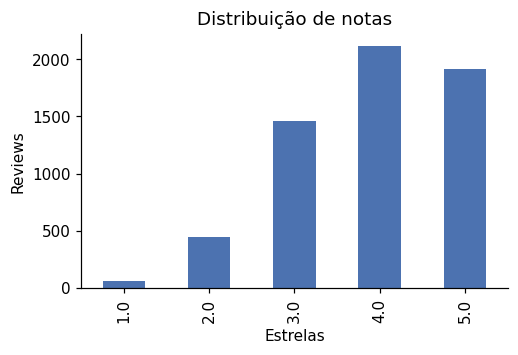

In [3]:
ax = df['review/score'].value_counts().sort_index().plot.bar(color='#4C72B0', figsize=(5, 3))
ax.set_title('Distribuição de notas'); ax.set_xlabel('Estrelas'); ax.set_ylabel('Reviews')
pct = (df['review/score'] >= 4).mean() * 100
print(f'{pct:.0f}% das reviews têm 4-5 estrelas -> H1 confirmada')

## 3. H5 — Cauda longa de volume
Curva de Pareto: se poucos livros concentram as reviews, a análise manual
"livro a livro" gasta a maior parte do tempo onde há pouco sinal.

28 livros (47%) concentram 80% das reviews -> H5 confirmada


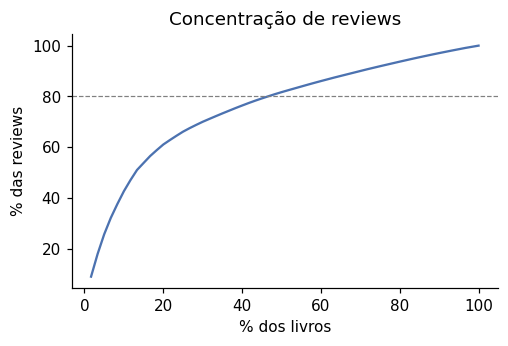

In [4]:
counts = df['Title'].value_counts().values
cum = np.cumsum(counts) / counts.sum()
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum * 100, color='#4C72B0')
ax.axhline(80, ls='--', c='gray', lw=0.8)
ax.set_xlabel('% dos livros'); ax.set_ylabel('% das reviews'); ax.set_title('Concentração de reviews')
n80 = int(np.searchsorted(cum, 0.8)) + 1
print(f'{n80} livros ({n80/len(counts)*100:.0f}%) concentram 80% das reviews -> H5 confirmada')

## 4. H3 — Sentimento do texto via supervisão fraca
**Ideia:** usar as próprias estrelas como rótulo (≥4 positivo, ≤2 negativo) para treinar
TF-IDF + Regressão Logística — zero custo de anotação, escala para o dataset inteiro.
O modelo então "lê" as reviews de 3★ (ambíguas por definição) e resolve a ambiguidade.

In [5]:
df, model = add_sentiment(df)
print('Performance no holdout (rótulos = estrelas):')
print(model.report_)

Performance no holdout (rótulos = estrelas):
              precision    recall  f1-score   support

         neg       1.00      0.91      0.95       102
         pos       0.99      1.00      0.99       807

    accuracy                           0.99       909
   macro avg       0.99      0.96      0.97       909
weighted avg       0.99      0.99      0.99       909



Nas 1,457 reviews 3 estrelas: 7% texto negativo, 79% texto positivo -> o texto desambigua a nota (H3)


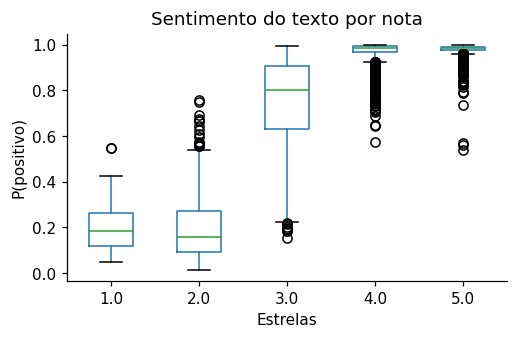

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
df.boxplot(column='sentiment', by='review/score', ax=ax, grid=False)
plt.suptitle(''); ax.set_title('Sentimento do texto por nota')
ax.set_xlabel('Estrelas'); ax.set_ylabel('P(positivo)')
amb = df[df['review/score'] == 3]
print(f"Nas {len(amb):,} reviews 3 estrelas: {(amb['sentiment']<0.4).mean()*100:.0f}% texto negativo, "
      f"{(amb['sentiment']>0.6).mean()*100:.0f}% texto positivo -> o texto desambigua a nota (H3)")

### Performance por autor — nota vs sentimento do texto
Para o negócio: dois autores com a mesma média de estrelas podem ter percepções
muito diferentes no texto.

,reviews,nota_media,sentimento
author,,,
Elena Marsh,101,4.752,0.974
Marina Vidal,481,4.586,0.968
Samuel Trent,148,4.561,0.967
Rachel Osei,126,4.587,0.954
Grace Holloway,110,4.545,0.949
Olivia Sterling,563,4.403,0.947
Alice Warren,132,4.288,0.939
Tessa Morrow,132,4.409,0.932
Isabel Navarro,169,3.970,0.890


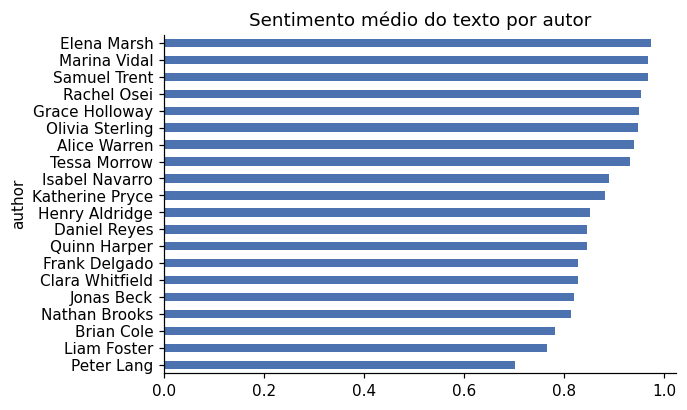

In [7]:
perf = (df.groupby('author')
        .agg(reviews=('review/score', 'size'), nota_media=('review/score', 'mean'),
             sentimento=('sentiment', 'mean'))
        .query('reviews >= 30').sort_values('sentimento', ascending=False).round(3))
display(perf.head(10))
ax = perf['sentimento'].plot.barh(color='#4C72B0', figsize=(6, 4))
ax.set_title('Sentimento médio do texto por autor'); ax.invert_yaxis()

## 5. H4 — Aspectos por gênero
Análise de aspectos (enredo, personagens, clareza, preço...) por dicionário +
polaridade da sentença. Em produção, a extração evolui para LLM few-shot
(mais recall), mantendo esta versão como baseline auditável.

Cada gênero tem um perfil próprio de elogios/críticas -> H4 confirmada


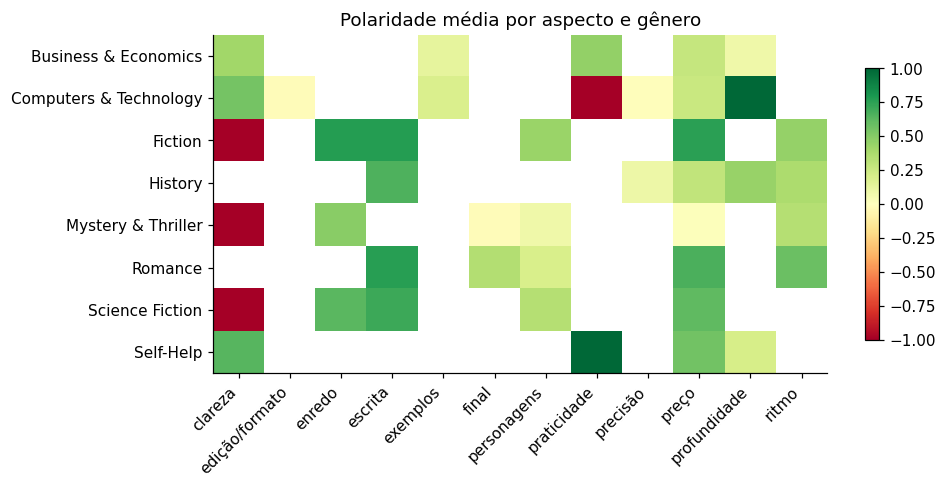

In [8]:
asp = aspect_sentiment(df).merge(df[['genre']], left_on='review_idx', right_index=True)
pivot = (asp[asp['polarity'] != 0].groupby(['genre', 'aspect'])['polarity']
         .mean().unstack().round(2))
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_title('Polaridade média por aspecto e gênero'); fig.colorbar(im, shrink=0.8)
print('Cada gênero tem um perfil próprio de elogios/críticas -> H4 confirmada')

## 6. Tópicos dominantes (NMF)
Visão não supervisionada do que os leitores falam — complementa os aspectos.

In [9]:
for i, topic in enumerate(extract_topics(df['review/text'], n_topics=6), 1):
    print(f'Tópico {i}: {", ".join(topic)}')

Tópico 1: far, truly, thorough, surface, goes, treatment, fast, paced
Tópico 2: read, story, characters, kept, constructed, masterfully, hooked, page
Tópico 3: day, examples, ideas, real, stick, world, concepts, chapter
Tópico 4: sentence, written, crafted, beautifully, feels, impossible, fast, paced
Tópico 5: read, research, analysis, impressive, perfect, sittings, finished, pleasure
Tópico 6: poor, editing, typos, sentences, awkward, painfully, slow, especially


## 7. H2 — Leitores relevantes para entrevista
Score composto: votos úteis da comunidade (35%), taxa de utilidade (25%),
profundidade do texto (20%), produtividade (10%) e discriminação de nota (10%).

In [10]:
conc = df.groupby('User_id')['helpful_votes'].sum().sort_values(ascending=False)
p10 = conc.head(max(1, len(conc)//10)).sum() / conc.sum() * 100
print(f'10% dos usuários concentram {p10:.0f}% dos votos de utilidade -> H2 confirmada')
rank_reviewers(df, top_k=10)[['profileName', 'n_reviews', 'total_helpful_votes',
                              'avg_len', 'avg_score', 'relevance_score']]

10% dos usuários concentram 47% dos votos de utilidade -> H2 confirmada


,profileName,n_reviews,total_helpful_votes,avg_len,avg_score,relevance_score
136,"Barbara Miller ""reviewer""",9,144,66.111111,2.888889,0.866
551,"Julie Thompson ""critic""",11,162,59.363636,3.363636,0.862
601,"Mark Johnson ""reader""",12,161,53.833333,3.250000,0.853
160,"Mary White ""bookworm""",9,124,63.444444,3.666667,0.849
186,"David Smith ""bookworm""",12,146,59.333333,3.166667,0.846
398,"Anna Davis ""critic""",11,172,60.000000,3.000000,0.843
96,"Barbara Clark ""critic""",10,153,57.000000,3.200000,0.841
67,"Barbara Harris ""critic""",10,137,56.800000,3.100000,0.837
616,"Anna Davis ""bookworm""",10,146,56.100000,3.600000,0.837
538,"Julie Martin ""reviewer""",9,143,59.777778,3.000000,0.833


## 8. Sumarização com LLM (map-reduce)
Demonstração com `LLM_PROVIDER=mock` (extrativa, offline). Em produção: Bedrock/Claude,
com o mesmo código — e cada chamada logada com tokens, custo e latência.

In [11]:
from src.llm_client import LLMClient
from src.summarizer import summarize_entity

autor = df['author'].value_counts().index[0]
print(summarize_entity(df[df['author'] == autor], f"autor '{autor}'", LLMClient('mock')))

[MODO DEMO — sumarização extrativa offline; em produção, LLM via Bedrock/OpenAI]

**Pontos fortes recorrentes:**
- The prose is elegant and a pleasure to read.
- The technical content is accurate and current.
- One of the best books I have read this year.
- The pacing is perfect, I finished it in two sittings.

**Críticas recorrentes:**
- Some technical sections are simply wrong.
- The pacing is painfully slow, especially in the middle.
- Superficial treatment of an important topic.
- The writing is clumsy and repetitive.


In [12]:
print('Observabilidade da POC (logs/llm_usage.jsonl):')
LLMClient.usage_report()

Observabilidade da POC (logs/llm_usage.jsonl):


{'calls': 11,
 'tokens_in': 24118,
 'tokens_out': 1364,
 'cost_usd': 0.0,
 'avg_latency_s': 0.06}

## Conclusões

As 5 hipóteses foram confirmadas na amostra, sustentando o desenho da solução:

1. **Automação com NLP clássico** resolve o volume (sentimento, aspectos, tópicos) a custo ~zero;
2. **LLM aplicado cirurgicamente** (sumarização executiva, futura base de conhecimento RAG) onde gera valor único;
3. **Ranking de leitores** transforma a busca por entrevistados de dias para segundos;
4. **Impacto:** ~R$ 20 mil/mês de capacidade analítica liberada (~R$ 240 mil/ano), análises 10x mais frequentes.

**Próximos passos:** ver roadmap AWS incremental no README (batch produtivo → RAG → escala e governança).